# Repulsive Bose-Einstein Model VMC

## Brute force Metropolis

Results for N = 10 (3D):
Minimum energy: 24.40
Minimum alpha: 0.50

Results for N = 100 (3D):
Minimum energy: 267.81
Minimum alpha: 0.47

Results for N = 2 (3D):
Minimum energy: 4.83
Minimum alpha: 0.47



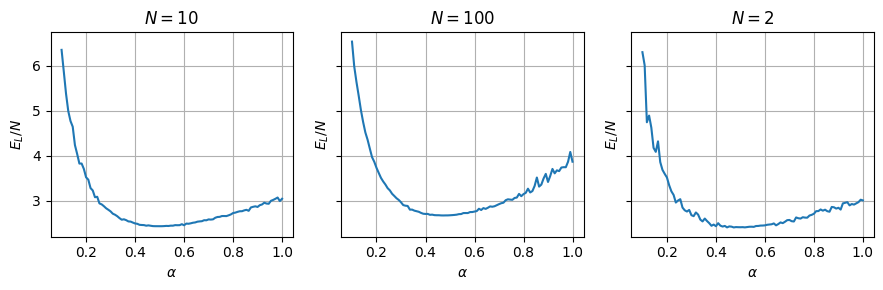

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_repulsive import BoseParamGrid
from bose_repulsive_jax import log_wavefunction_jax, local_energy_jax, BoseParams

base_cycles = 100_000
base_step = 0.5

alpha_values = np.linspace(0.1, 1.0, 100)
beta_values = np.array([2.82843])
a_values = np.array([0.0043])

param_grid = BoseParamGrid(
  param_type=BoseParams,
  alpha=alpha_values,
  beta=beta_values,
  gamma=beta_values,
  a=a_values,
)

number_particles = [10, 100, 500]
dim = 3

for n in number_particles:

  #step_size = base_step / np.sqrt(n)

  simulation = MetropolisJAX[BoseParams](n, dim)
  result = simulation.grid_search_brute(
    log_wavefunction_jax, local_energy_jax, param_grid, base_step, base_cycles
  )

  energies = result.energies
  plt.plot(alpha_values, energies / n, label=rf"$N = {n}$")

  min_energy = np.min(energies)
  min_alpha = alpha_values[np.argmin(energies)]
  print(f"Results for N = {n} (3D):")
  print(f"Minimum energy: {min_energy:.3f}")
  print(f"Minimum alpha: {min_alpha:.3f}")
  print(f"Mean accept rates: {np.mean(result.accept_rates):.3f}\n")

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\langle E \rangle /N$")
plt.legend()
plt.grid(True)
# plt.savefig("vmc_bose_repulsive_grid_brute.pdf", format="pdf")
plt.show()


## Metropolis with importance sampling

Results for N = 10 (3D):
Minimum energy: 24.401
Minimum alpha: 0.491
Mean accept rates: 0.944

Results for N = 100 (3D):
Minimum energy: 267.758
Minimum alpha: 0.473
Mean accept rates: 0.716

Results for N = 500 (3D):
Minimum energy: 1749.860
Minimum alpha: 0.418
Mean accept rates: 0.044



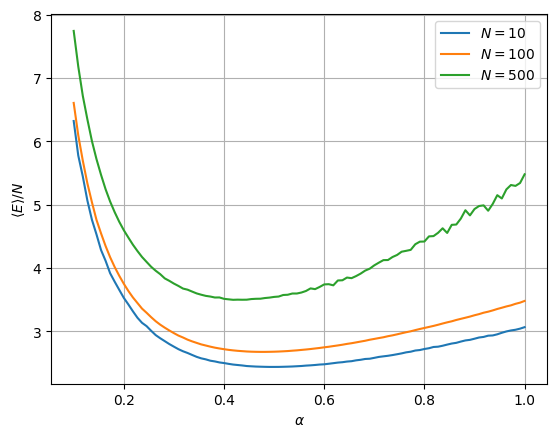

In [6]:
import matplotlib.pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_repulsive import BoseParamGrid
from bose_repulsive_jax import log_wavefunction_jax, local_energy_jax, drift_force_jax, BoseParams

base_cycles = 100_000
base_dt = 0.05
diffusion_coefficient = 0.5

alpha_values = np.linspace(0.1, 1.0, 100)
beta_values = np.array([2.82843])
a_values = np.array([0.0043])

param_grid = BoseParamGrid(
  param_type=BoseParams,
  alpha=alpha_values,
  beta=beta_values,
  gamma=beta_values,
  a=a_values,
)

number_particles = [10, 100, 500]
dim = 3

for n in number_particles:
  #time_step = base_dt / np.sqrt(n)

  simulation = MetropolisJAX[BoseParams](n, dim)
  result = simulation.grid_search_importance(
    log_wavefunction_jax, local_energy_jax, drift_force_jax, param_grid, base_dt, diffusion_coefficient, base_cycles,
  )

  energies = result.energies
  plt.plot(alpha_values, energies / n, label=rf"$N = {n}$")

  min_energy = np.min(energies)
  min_alpha = alpha_values[np.argmin(energies)]
  print(f"Results for N = {n} (3D):")
  print(f"Minimum energy: {min_energy:.3f}")
  print(f"Minimum alpha: {min_alpha:.3f}")
  print(f"Mean accept rates: {np.mean(result.accept_rates):.3f}\n")

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\langle E \rangle /N$")
plt.legend()
plt.grid(True)
plt.savefig("vmc_bose_repulsive_grid_importance_analytic.pdf", format="pdf")
plt.show()

## Parameter optimization

In [ ]:
import jax.numpy as jnp
import numpy as np
import optax

from bose_repulsive_jax import (
  log_wavefunction_jax,
  wavefunction_derivative_jax,
  local_energy_jax,
  drift_force_jax,
  BoseParams,
)
from vmc_jax import MetropolisJAX
from stats import timeseries_bootstrap
from structs import OptimizationRecord, records_to_markdown

cycles_optimize = 100_000
cycles_sample = 2**20
time_step = 0.05
diffusion_coefficient = 0.5
optimization_iterations = 200
base_lr = 0.01
bootstrap_samples = 2**12
block_size = 2**10

number_particles = [10, 100, 500]
dim = 3

alpha_value = jnp.array(0.5)
beta_value = jnp.array(2.82843)
a_value = jnp.array(0.0043)

lr_schedule = optax.warmup_cosine_decay_schedule(
  init_value=0.0,
  peak_value=base_lr,
  warmup_steps=optimization_iterations // 10,
  decay_steps=optimization_iterations,
  end_value=base_lr * 1e-2,
)

optimizer = optax.chain(
  optax.clip_by_global_norm(1.0),
  optax.adam(lr_schedule),
)

parameter_guess = BoseParams(alpha=alpha_value, beta=beta_value, gamma=beta_value, a=a_value)

records: list[OptimizationRecord] = []
for n in number_particles:
  print(f"Optimizing for {n} particles")

  # Optimize parameters
  simulation = MetropolisJAX[BoseParams](n, dim)

  energy, parameters = simulation.optimize(
    log_wavefunction_jax,
    wavefunction_derivative_jax,
    local_energy_jax,
    drift_force_jax,
    parameter_guess,
    time_step,
    diffusion_coefficient,
    cycles_optimize,
    optimization_iterations,
    optimizer,
  )

  # Bootstrap analysis
  _, _, _, energies = simulation.sample_importance(
    log_wavefunction_jax,
    local_energy_jax,
    drift_force_jax,
    parameters,
    time_step,
    diffusion_coefficient,
    cycles_sample,
  )

  bootstrap_result = timeseries_bootstrap(np.array(energies), np.mean, bootstrap_samples, block_size)

  records.append(OptimizationRecord(
    n=n,
    alpha=float(parameters.alpha),
    mean=bootstrap_result.statistic / n,
    error=bootstrap_result.standard_error / n,
    bias=bootstrap_result.bias / n,
  ))

field_map = {
  "n": ("$N$", None),
  "alpha": (r"$\alpha$", ".4f"),
  "mean": (r"$\braket{E}$", ".4f"),
  "error": (r"$\operatorname{var}(E)/N$", ".3e"),
  "bias":  (r"\operatorname{bias}(E)/N", ".3e")
}
md_table = records_to_markdown(records, field_map)
print(md_table)

Optimizing for 10 particles
iteration 0/200: E=2.45, grad=2.057e-02, BoseParams(alpha=Array(0.5, dtype=float32), beta=Array(2.82843, dtype=float32), gamma=Array(2.82843, dtype=float32), a=Array(0.0043, dtype=float32))
iteration 10/200: E=2.42, grad=1.964e-02, BoseParams(alpha=Array(0.48632956, dtype=float32), beta=Array(2.82843, dtype=float32), gamma=Array(2.82843, dtype=float32), a=Array(0.0043, dtype=float32))
iteration 20/200: E=2.43, grad=6.195e-03, BoseParams(alpha=Array(0.48847905, dtype=float32), beta=Array(2.82843, dtype=float32), gamma=Array(2.82843, dtype=float32), a=Array(0.0043, dtype=float32))
iteration 30/200: E=2.53, grad=3.683e-01, BoseParams(alpha=Array(0.4725699, dtype=float32), beta=Array(2.82843, dtype=float32), gamma=Array(2.82843, dtype=float32), a=Array(0.0043, dtype=float32))
iteration 40/200: E=2.40, grad=4.874e-02, BoseParams(alpha=Array(0.47936052, dtype=float32), beta=Array(2.82843, dtype=float32), gamma=Array(2.82843, dtype=float32), a=Array(0.0043, dtype=f